In [1]:
#Traffic analysis 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta
import warnings

In [17]:
df = pd.read_excel('/home/thomas/backup-sensor-data/dynamic_weight/Marzo/16 marzo - 22 marzo/1.xlsx')
df.head(10)

,Id,StartTime,StartTimeStr,LaneNo,LaneName,BaseClassId,Scheme,ClassId,MoveStatus,FrontToFront,...,WheelBase,FrontOverhang,AxlesCount,MassUnit,VelocityUnit,DistanceUnit,WheelType,StrongAcceleration,StrongDeceleration,DateTimeTransit
0,949997,1742080000000,15/03/2025 23:00,3,Corsia 2 - Marcia veloce,21,EUR13,1,1,15.685,...,2.68,0.17,2,kg,km/h,m,N,0,0,15/03/2025 23:00
1,949998,1742080000000,15/03/2025 23:00,2,Corsia 1 - Marcia,2,EUR13,12,-1,33.209,...,4.31,0.25,2,kg,km/h,m,S,0,0,15/03/2025 23:00
2,949999,1742080000000,15/03/2025 23:00,3,Corsia 2 - Marcia veloce,21,EUR13,1,-1,36.706,...,2.64,0.37,2,kg,km/h,m,N,0,0,15/03/2025 23:00
3,950000,1742080000000,15/03/2025 23:00,2,Corsia 1 - Marcia,15,EUR13,9,-1,36.045,...,12.19,1.35,5,kg,km/h,m,D,0,0,15/03/2025 23:00
4,950001,1742080000000,15/03/2025 23:01,3,Corsia 2 - Marcia veloce,21,EUR13,1,1,52.295,...,2.71,0.51,2,kg,km/h,m,N,0,0,15/03/2025 23:01
5,950002,1742080000000,15/03/2025 23:01,3,Corsia 2 - Marcia veloce,21,EUR13,1,1,17.680,...,2.30,0.74,2,kg,km/h,m,N,0,0,15/03/2025 23:01
6,950003,1742080000000,15/03/2025 23:02,3,Corsia 2 - Marcia veloce,21,EUR13,1,1,33.906,...,2.58,0.12,2,kg,km/h,m,N,0,0,15/03/2025 23:02
7,950004,1742080000000,15/03/2025 23:02,3,Corsia 2 - Marcia veloce,21,EUR13,1,1,9.171,...,2.77,0.40,2,kg,km/h,m,N,0,0,15/03/2025 23:02
8,950005,1742080000000,15/03/2025 23:02,3,Corsia 2 - Marcia veloce,21,EUR13,1,1,11.166,...,2.44,0.16,2,kg,km/h,m,N,0,0,15/03/2025 23:02
9,950006,1742080000000,15/03/2025 23:02,2,Corsia 1 - Marcia,21,EUR13,1,-1,115.143,...,2.69,0.38,2,kg,km/h,m,S,0,0,15/03/2025 23:02


In [18]:
df['ClassId'].unique()
df.groupby(by='ClassId').count()
print(df['GrossWeight'].max())
print(df['GrossWeight'].min())
print(df['GrossWeight'].mean())
print(df['Velocity'].max())
print(df['Velocity'].min())
print(df['Velocity'].mean())

65400
0
6259.7962
378
0
120.29637


In [32]:
#filtering every 15min vehciles data by hardcoding the index from the excels sheets
df_filtered = df[42814:42853]
print(df_filtered)

           Id      StartTime      StartTimeStr  LaneNo  \
42814  993024  1742260000000  18/03/2025 00:46       3   
42815  993025  1742260000000  18/03/2025 00:46       3   
42816  993026  1742260000000  18/03/2025 00:46       3   
42817  993027  1742260000000  18/03/2025 00:47       2   
42818  993028  1742260000000  18/03/2025 00:47       2   
42819  993029  1742260000000  18/03/2025 00:47       3   
42820  993030  1742260000000  18/03/2025 00:47       2   
42821  993031  1742260000000  18/03/2025 00:47       2   
42822  993032  1742260000000  18/03/2025 00:47       2   
42823  993033  1742260000000  18/03/2025 00:48       2   
42824  993034  1742260000000  18/03/2025 00:48       2   
42825  993035  1742260000000  18/03/2025 00:47       3   
42826  993036  1742260000000  18/03/2025 00:48       2   
42827  993037  1742260000000  18/03/2025 00:48       2   
42828  993038  1742260000000  18/03/2025 00:48       2   
42829  993039  1742260000000  18/03/2025 00:48       2   
42830  993040 

In [33]:
df_filtered.columns

Index(['Id', 'StartTime', 'StartTimeStr', 'LaneNo', 'LaneName', 'BaseClassId',
       'Scheme', 'ClassId', 'MoveStatus', 'FrontToFront', 'BackToFront',
       'Duration', 'VehicleLength', 'GrossWeight', 'LeftWeight', 'RightWeight',
       'Velocity', 'WheelBase', 'FrontOverhang', 'AxlesCount', 'MassUnit',
       'VelocityUnit', 'DistanceUnit', 'WheelType', 'StrongAcceleration',
       'StrongDeceleration', 'DateTimeTransit'],
      dtype='object')

In [34]:
df_export = df_filtered[['StartTimeStr', 'Velocity', 'GrossWeight', 'AxlesCount' ]]

In [35]:
df_export

,StartTimeStr,Velocity,GrossWeight,AxlesCount
42814,18/03/2025 00:46,103,1120,2
42815,18/03/2025 00:46,111,2500,2
42816,18/03/2025 00:46,104,3280,2
42817,18/03/2025 00:47,93,3170,2
42818,18/03/2025 00:47,90,17920,4
42819,18/03/2025 00:47,93,1490,2
42820,18/03/2025 00:47,90,17120,5
42821,18/03/2025 00:47,90,7480,2
42822,18/03/2025 00:47,90,14450,3
42823,18/03/2025 00:48,96,39730,5


In [36]:
#creating 15min intreval csv files for tracking the vehicles
path = '/home/thomas/industry_time_series/src/research/csv/timestamps_18_03_2025_45-00min.csv'

df_export.to_csv(path, index=False)

In [128]:
df = df[df['GrossWeight'] > 30000]


#df = df[df['ClassId'] == 13]

df['momentum'] = df['GrossWeight'] * df['Velocity']

print(df['GrossWeight'].max())
print(df['GrossWeight'].min())
print(df['GrossWeight'].mean())
print(df['Velocity'].max())
print(df['Velocity'].min())
print(df['Velocity'].mean())

print(df.shape)

64660
30020
39936.66948198198
99
68
87.759009009009
(3552, 28)


In [129]:
df_mom = df['momentum']
df_mom.astype(int)

#print(df_mom.describe())

print(df_mom.max())

print(df_mom.min())

5860400
2264400


Axes(0.125,0.11;0.775x0.77)


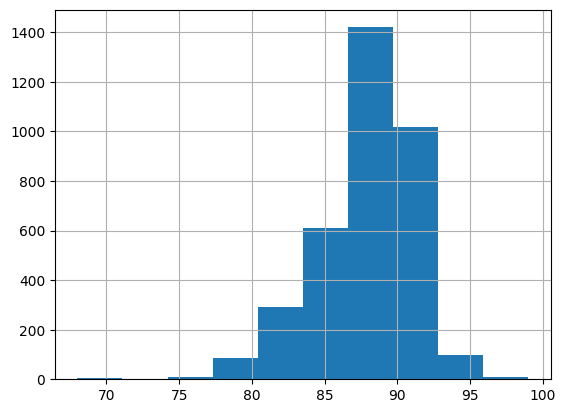

In [130]:

#print(df['GrossWeight'].hist()) 
print(df['Velocity'].hist())

#print(df['momentum'].hist())



In [131]:
df.groupby(by='ClassId').count()

,Id,StartTime,StartTimeStr,LaneNo,LaneName,BaseClassId,Scheme,MoveStatus,FrontToFront,BackToFront,Duration,VehicleLength,GrossWeight,LeftWeight,RightWeight,Velocity,WheelBase,FrontOverhang,AxlesCount,MassUnit,VelocityUnit,DistanceUnit,WheelType,StrongAcceleration,StrongDeceleration,DateTimeTransit,momentum
ClassId,,,,,,,,,,,,,,,,,,,,,,,,,,,
3,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
4,24,24,24,24,24,24,24,24,24,24,24,24,24,24,24,24,24,24,24,24,24,24,24,24,24,24,24
5,24,24,24,24,24,24,24,24,24,24,24,24,24,24,24,24,24,24,24,24,24,24,24,24,24,24,24
6,148,148,148,148,148,148,148,148,148,148,148,148,148,148,148,148,148,148,148,148,148,148,148,148,148,148,148
8,63,63,63,63,63,63,63,63,63,63,63,63,63,63,63,63,63,63,63,63,63,63,63,63,63,63,63
9,3184,3184,3184,3184,3184,3184,3184,3184,3184,3184,3184,3184,3184,3184,3184,3184,3184,3184,3184,3184,3184,3184,3184,3184,3184,3184,3184
10,54,54,54,54,54,54,54,54,54,54,54,54,54,54,54,54,54,54,54,54,54,54,54,54,54,54,54
11,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7
13,47,47,47,47,47,47,47,47,47,47,47,47,47,47,47,47,47,47,47,47,47,47,47,47,47,47,47


In [132]:
df = df[1809:2000]


In [133]:

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [134]:
df_timestamp = df[['StartTimeStr']]
pd.to_datetime(df_timestamp['StartTimeStr'])



24505   2025-07-03 00:18:00
24556   2025-07-03 01:11:00
24557   2025-07-03 01:11:00
24572   2025-07-03 01:27:00
24607   2025-07-03 01:58:00
24609   2025-07-03 01:59:00
24626   2025-07-03 02:07:00
24636   2025-07-03 02:14:00
24641   2025-07-03 02:19:00
24659   2025-07-03 02:32:00
24665   2025-07-03 02:35:00
24687   2025-07-03 02:50:00
24689   2025-07-03 02:52:00
24692   2025-07-03 02:54:00
24700   2025-07-03 02:58:00
24701   2025-07-03 03:00:00
24709   2025-07-03 03:05:00
24721   2025-07-03 03:12:00
24732   2025-07-03 03:16:00
24744   2025-07-03 03:19:00
24749   2025-07-03 03:20:00
24760   2025-07-03 03:25:00
24765   2025-07-03 03:26:00
24774   2025-07-03 03:31:00
24777   2025-07-03 03:32:00
24779   2025-07-03 03:33:00
24780   2025-07-03 03:33:00
24781   2025-07-03 03:33:00
24784   2025-07-03 03:34:00
24789   2025-07-03 03:35:00
24791   2025-07-03 03:36:00
24798   2025-07-03 03:39:00
24817   2025-07-03 03:46:00
24818   2025-07-03 03:47:00
24832   2025-07-03 03:51:00
24834   2025-07-03 0

In [135]:
df_timestamp = df_timestamp.head(10)
#df_timestamp.tail()


In [136]:
df_timestamp

,StartTimeStr
24505,2025-07-03 00:18:00
24556,2025-07-03 01:11:00
24557,2025-07-03 01:11:00
24572,2025-07-03 01:27:00
24607,2025-07-03 01:58:00
24609,2025-07-03 01:59:00
24626,2025-07-03 02:07:00
24636,2025-07-03 02:14:00
24641,2025-07-03 02:19:00
24659,2025-07-03 02:32:00


In [137]:
df_timestamp['StartTimeStr'] = pd.to_datetime(df_timestamp['StartTimeStr'])
df_timestamp['timedelta_minutes'] = df_timestamp['StartTimeStr'].diff().dt.total_seconds()/60

df_timestamp = df_timestamp.iloc[0:-1]
print(df_timestamp['timedelta_minutes'])

df_out = df_timestamp[df_timestamp['timedelta_minutes'] > 5]

24505     NaN
24556    53.0
24557     0.0
24572    16.0
24607    31.0
24609     1.0
24626     8.0
24636     7.0
24641     5.0
Name: timedelta_minutes, dtype: float64


In [138]:
df_out
df_out.to_csv('/Users/thomas/Desktop/github_repos/industry_time_series/src/research/timestamps_collection.csv')

In [139]:
df = pd.read_csv('/Users/thomas/Desktop/github_repos/industry_time_series/src/research/scripts/res.csv')

In [140]:
df

,source_event_id,original_timestamp,detected_vehicle_id,03091010_x_first_peak,03091010_x_peak,03091203_x_first_peak,03091203_x_peak,03091153_x_first_peak,03091153_x_peak,0309101F_x_first_peak,0309101F_x_peak,0309120E_x_first_peak,0309120E_x_peak,030911D2_x_first_peak,030911D2_x_peak,03091211_x_first_peak,03091211_x_peak,03091036_x_first_peak,03091036_x_peak,03091118_x_first_peak,03091118_x_peak,03091048_x_first_peak,03091048_x_peak,03091115_x_first_peak,03091115_x_peak,03091014_x_first_peak,03091014_x_peak,03091132_x_first_peak,03091132_x_peak,03091113_x_first_peak,03091113_x_peak,030910F7_x_first_peak,030910F7_x_peak,03091008_x_first_peak,03091008_x_peak,030911D3_x_first_peak,030911D3_x_peak,03091019_x_first_peak,03091019_x_peak,03091202_x_first_peak,03091202_x_peak,03091201_x_first_peak,03091201_x_peak,030911ED_x_first_peak,030911ED_x_peak,0309114E_x_first_peak,0309114E_x_peak,03091041_x_first_peak,03091041_x_peak,03091204_x_first_peak,03091204_x_peak,0309120B_x_first_peak,0309120B_x_peak,0309101D_x_first_peak,0309101D_x_peak,0309114D_x_first_peak,0309114D_x_peak,03091002_x_first_peak,03091002_x_peak,030911F2_x_first_peak,030911F2_x_peak,03091128_x_first_peak,03091128_x_peak,030911E0_x_first_peak,030911E0_x_peak,03091012_x_first_peak,03091012_x_peak,03091126_x_first_peak,03091126_x_peak,0309112F_x_first_peak,0309112F_x_peak,03091042_x_first_peak,03091042_x_peak,03091032_x_first_peak,03091032_x_peak,0309102D_x_first_peak,0309102D_x_peak,03091007_x_first_peak,03091007_x_peak,03091043_x_first_peak,03091043_x_peak,030911EC_x_first_peak,030911EC_x_peak
0,v1,2025-07-03 01:11:00,v1_d1,2025-03-07 01:12:49.850,2025-03-07 01:12:53.880,2025-03-07 01:16:10.130,2025-03-07 01:16:10.300,2025-03-07 01:16:10.130,2025-03-07 01:16:10.300,2025-03-07 01:16:10.130,2025-03-07 01:16:10.300,2025-03-07 01:16:10.480,2025-03-07 01:16:11.820,2025-03-07 01:16:10.480,2025-03-07 01:16:11.820,2025-03-07 01:16:10.480,2025-03-07 01:16:11.820,2025-03-07 01:16:10.480,2025-03-07 01:16:11.820,2025-03-07 01:16:10.480,2025-03-07 01:16:11.820,2025-03-07 01:16:10.480,2025-03-07 01:16:11.820,2025-03-07 01:16:10.480,2025-03-07 01:16:11.820,2025-03-07 01:16:10.480,2025-03-07 01:16:11.820,2025-03-07 01:16:10.480,2025-03-07 01:16:11.820,2025-03-07 01:16:10.480,2025-03-07 01:16:11.820,2025-03-07 01:16:10.480,2025-03-07 01:16:11.820,2025-03-07 01:16:10.480,2025-03-07 01:16:11.820,2025-03-07 01:16:10.480,2025-03-07 01:16:11.820,2025-03-07 01:16:10.480,2025-03-07 01:16:11.820,2025-03-07 01:16:10.480,2025-03-07 01:16:11.820,2025-03-07 01:16:10.480,2025-03-07 01:16:11.820,2025-03-07 01:16:10.480,2025-03-07 01:16:11.820,2025-03-07 01:16:10.480,2025-03-07 01:16:11.820,2025-03-07 01:16:10.480,2025-03-07 01:16:11.820,2025-03-07 01:16:10.480,2025-03-07 01:16:11.820,2025-03-07 01:16:10.480,2025-03-07 01:16:11.820,2025-03-07 01:16:10.480,2025-03-07 01:16:11.820,2025-03-07 01:16:10.480,2025-03-07 01:16:11.820,2025-03-07 01:16:10.480,2025-03-07 01:16:11.820,2025-03-07 01:16:10.480,2025-03-07 01:16:11.820,2025-03-07 01:16:10.480,2025-03-07 01:16:11.820,2025-03-07 01:16:10.480,2025-03-07 01:16:11.820,2025-03-07 01:16:10.480,2025-03-07 01:16:11.820,2025-03-07 01:16:10.480,2025-03-07 01:16:11.820,2025-03-07 01:16:10.480,2025-03-07 01:16:11.820,2025-03-07 01:16:10.480,2025-03-07 01:16:11.820,2025-03-07 01:16:10.480,2025-03-07 01:16:11.820,2025-03-07 01:16:10.480,2025-03-07 01:16:11.820,2025-03-07 01:16:10.480,2025-03-07 01:16:11.820,2025-03-07 01:16:10.480,2025-03-07 01:16:11.820,2025-03-07 01:16:10.480,2025-03-07 01:16:11.820
1,v2,2025-07-03 01:27:00,v2_d1,2025-03-07 01:32:00.320,2025-03-07 01:32:04.350,2025-03-07 01:32:00.320,2025-03-07 01:32:04.350,2025-03-07 01:32:00.320,2025-03-07 01:32:04.350,2025-03-07 01:32:00.320,2025-03-07 01:32:04.350,2025-03-07 01:32:00.480,2025-03-07 01:32:05.860,2025-03-07 01:32:00.480,2025-03-07 01:32:05.860,2025-03-07 01:32:00.480,2025-03-07 01:32:05.860,2025-03-07 01:32:00.480,2025-03-07 01:32:05.860,2025-03-07 01:32:06.040,2025-03-07 01:32:10.350,2025-03-07